# 🛡️ Level 2 - Project 3: Fraud Detection Pipeline

**Domain:** Anomaly Detection & Binary Classification  
**Internship Track:** Data Analytics Internship (Oasis Infobyte)  
**Author:** Akshay Anil Kumar  

---

## 1. Automated Extraction & Class Imbalance Audit
This stage automatically scans the workspace for the project archive, extracts the data tables, and inspects the distribution ratio between legitimate transactions and fraudulent activity.

In [4]:
import zipfile
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# 1. Find all zip files in the current folder
zip_files = glob.glob("*.zip")
print(f"🔍 Found {len(zip_files)} zip file(s) in folder.")

fraud_zip = None
for z in zip_files:
    lower_name = z.lower()
    if any(keyword in lower_name for keyword in ["fraud", "credit", "card", "transaction", "archive"]):
        with zipfile.ZipFile(z, 'r') as zip_ref:
            members = zip_ref.namelist()
            print(f"\n📦 Archive: {z}")
            for m in members:
                print(f"  - {m}")
            if any(any(keyword in m.lower() for keyword in ["fraud", "credit", "card", "transaction"]) for m in members):
                fraud_zip = z
                break

if fraud_zip is None and zip_files:
    # Fall back to the first zip if no strong keyword match was found
    fraud_zip = zip_files[0]
    print(f"\n⚠️ No obvious fraud archive name found; falling back to first zip: {fraud_zip}")

if fraud_zip:
    print(f"\n✅ Extracting archive: {fraud_zip}")
    with zipfile.ZipFile(fraud_zip, 'r') as zip_ref:
        zip_ref.extractall('.')
    print("✓ Extraction complete!")
else:
    print("⚠️ No zip archive found to extract.")

# 2. Locate candidate CSVs after extraction
csv_candidates = (
    glob.glob("*fraud*.csv") +
    glob.glob("*credit*.csv") +
    glob.glob("*card*.csv") +
    glob.glob("*transaction*.csv") +
    glob.glob("*.csv")
)
csv_candidates = [c for c in csv_candidates if all(exclude not in c.lower() for exclude in ["housing", "wine", "menu", "retail"])]

print(f"\n🔎 Found {len(csv_candidates)} candidate CSV file(s).")
for idx, candidate in enumerate(csv_candidates, 1):
    print(f"  {idx}. {candidate}")

if not csv_candidates:
    raise FileNotFoundError("❌ Could not find any fraud-related CSV file after extraction.")

# 3. Load the first likely fraud dataset
csv_files = [c for c in csv_candidates if any(keyword in c.lower() for keyword in ["fraud", "credit", "card", "transaction"])]
if not csv_files:
    csv_files = csv_candidates

csv_file = csv_files[0]
print(f"\n📊 Loading dataset from: '{csv_file}'")
df = pd.read_csv(csv_file)
print(f"✓ Data successfully loaded. Shape: {df.shape}")

# 4. Identify the target column and preview the data
target_cols = [col for col in df.columns if col.lower() in ['class', 'is_fraud', 'fraud', 'target']]
if not target_cols:
    raise ValueError(f"❌ No fraud target column found in CSV columns: {list(df.columns)}")

target_col = target_cols[0]
print(f"Target column: {target_col}")
print("\n=== Class Distribution (0 = Normal, 1 = Fraud) ===")
print(df[target_col].value_counts())
print("\n=== Dataset Structure Preview ===")
display(df.head())

🔍 Found 4 zip file(s) in folder.

📦 Archive: archive (1).zip
  - menu.csv

📦 Archive: archive 2.zip
  - WineQT.csv

📦 Archive: archive 3.zip
  - creditcard.csv

✅ Extracting archive: archive 3.zip
✓ Extraction complete!

🔎 Found 3 candidate CSV file(s).
  1. creditcard.csv
  2. creditcard.csv
  3. creditcard.csv

📊 Loading dataset from: 'creditcard.csv'
✓ Data successfully loaded. Shape: (284807, 31)
Target column: Class

=== Class Distribution (0 = Normal, 1 = Fraud) ===
Class
0    284315
1       492
Name: count, dtype: int64

=== Dataset Structure Preview ===


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Feature Isolation & Partitioning
We split our independent variables from the target tracking class and partition the structural metrics into an **80% training matrix** and a **20% testing split** using stratified matching to preserve the fraud ratio.

In [5]:
# Separate features and target
X = df.drop([target_col], axis=1)
y = df[target_col]

# Use stratify=y to make sure both training and testing sets get an equal percentage of fraud cases
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training features size: {X_train.shape}")
print(f"Testing features size: {X_test.shape}")

Training features size: (227845, 30)
Testing features size: (56962, 30)


## 3. Classifier Model Training & Performance Verification
We train an ensemble Random Forest model to flag highly suspicious structural parameters and map the classification errors using a precision-focused confusion matrix.

=== Performance Evaluation ===
Overall Accuracy: 99.96%
Area Under ROC Curve (ROC-AUC): 0.9081

=== Detailed Classification Summary ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



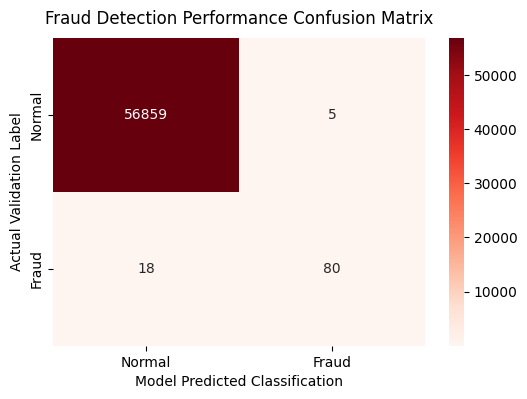

In [6]:
# Initialize and fit the model
fraud_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
fraud_model.fit(X_train, y_train)

# Run test predictions
y_pred = fraud_model.predict(X_test)

print("=== Performance Evaluation ===")
print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"Area Under ROC Curve (ROC-AUC): {roc_auc_score(y_test, y_pred):.4f}\n")
print("=== Detailed Classification Summary ===")
print(classification_report(y_test, y_pred))

# Render Confusion Matrix
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Reds', 
            xticklabels=['Normal', 'Fraud'], yticklabels=['Normal', 'Fraud'])
plt.title('Fraud Detection Performance Confusion Matrix', fontsize=12, pad=10)
plt.xlabel('Model Predicted Classification')
plt.ylabel('Actual Validation Label')
plt.show()